In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("online_retail_II.xlsx.csv", encoding="latin1")

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  str    
 1   StockCode    541910 non-null  str    
 2   Description  540456 non-null  str    
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  str    
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
None


In [4]:
print(df.describe())

            Quantity          Price    Customer ID
count  541910.000000  541910.000000  406830.000000
mean        9.552234       4.611138   15287.684160
std       218.080957      96.759765    1713.603074
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


In [5]:
df.isnull().sum().sort_values(ascending=False)

Customer ID    135080
Description      1454
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['InvoiceDate'].isnull().sum()

np.int64(308950)

In [8]:
df = df[df['InvoiceDate'].notna()]
df['InvoiceDate'].isnull().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()
df.isnull().sum()
df_clean = df.dropna(subset=['Customer ID'])

In [10]:
returns = df_clean[df_clean['Quantity'] < 0]
df_clean = df_clean[df_clean['Quantity'] > 0]

In [11]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

In [12]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 166382 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      166382 non-null  str           
 1   StockCode    166382 non-null  str           
 2   Description  166382 non-null  str           
 3   Quantity     166382 non-null  int64         
 4   InvoiceDate  166382 non-null  datetime64[us]
 5   Price        166382 non-null  float64       
 6   Customer ID  166382 non-null  float64       
 7   Country      166382 non-null  str           
 8   Revenue      166382 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 12.7 MB


In [13]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue

Country
United Kingdom          3263199.25
EIRE                      97282.79
Germany                   93933.59
Netherlands               89850.96
France                    85072.61
Australia                 49209.71
Switzerland               27692.51
Spain                     24993.20
Japan                     17134.16
Belgium                   16942.55
Norway                    14655.10
Portugal                  13139.82
Finland                   11357.60
Sweden                     9316.36
Singapore                  8209.58
Channel Islands            7894.96
Cyprus                     5385.91
Denmark                    4863.56
Poland                     3904.21
Italy                      3664.11
Austria                    2999.69
Iceland                    2540.29
USA                        2464.75
Greece                     2099.28
Canada                     1751.88
Lithuania                  1661.06
Unspecified                1151.78
United Arab Emirates        975.54
Malta       

<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='Country'>

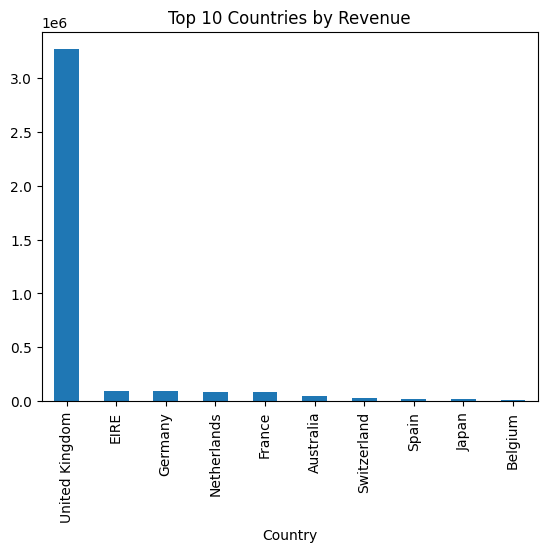

In [15]:
country_revenue.head(10).plot(kind='bar', title='Top 10 Countries by Revenue')

In [16]:
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER               62383.41
WHITE HANGING HEART T-LIGHT HOLDER     47903.18
PICNIC BASKET WICKER 60 PIECES         39619.50
JUMBO BAG RED RETROSPOT                37977.38
POSTAGE                                35265.15
ASSORTED COLOUR BIRD ORNAMENT          28457.85
PARTY BUNTING                          28236.87
Manual                                 26016.79
BLACK RECORD COVER FRAME               22443.26
Name: Revenue, dtype: float64

In [17]:
df_clean = df_clean[~df_clean['Description'].isin(['POSTAGE', 'Manual'])]
top_products = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER               62383.41
WHITE HANGING HEART T-LIGHT HOLDER     47903.18
PICNIC BASKET WICKER 60 PIECES         39619.50
JUMBO BAG RED RETROSPOT                37977.38
ASSORTED COLOUR BIRD ORNAMENT          28457.85
PARTY BUNTING                          28236.87
BLACK RECORD COVER FRAME               22443.26
CHILLI LIGHTS                          21040.03
PAPER CHAIN KIT 50'S CHRISTMAS         20489.10
Name: Revenue, dtype: float64

In [18]:
df_clean['HighValue'] = df_clean['Revenue'] > df_clean['Revenue'].quantile(0.9)
pd.crosstab(df_clean['Country'], df_clean['HighValue'])

HighValue,False,True
Country,,
Australia,141,240
Austria,89,13
Bahrain,10,3
Belgium,765,43
Canada,76,2
Channel Islands,329,33
Cyprus,210,23
Czech Republic,7,2
Denmark,92,35


In [19]:
country_counts = df_clean.groupby('Country')['HighValue'].count()
high_value_counts = df_clean[df_clean['HighValue'] == True].groupby('Country')['HighValue'].count()
high_value_rate = (high_value_counts / country_counts).fillna(0).sort_values(ascending=False)
high_value_rate

Country
Lithuania               0.685714
Netherlands             0.680101
Australia               0.629921
Japan                   0.590909
Singapore               0.480769
Sweden                  0.282759
Denmark                 0.275591
Switzerland             0.238788
Bahrain                 0.230769
Norway                  0.224176
Czech Republic          0.222222
EIRE                    0.175143
Finland                 0.154971
United Arab Emirates    0.135135
Austria                 0.127451
Iceland                 0.122642
Italy                   0.120805
Germany                 0.120113
European Community      0.105263
Cyprus                  0.098712
France                  0.093493
Channel Islands         0.091160
United Kingdom          0.088158
Poland                  0.085106
Portugal                0.072404
Spain                   0.066528
Belgium                 0.053218
USA                     0.045113
Canada                  0.025641
Greece                  0.018182
Un

In [20]:
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)

Customer ID
16446.0    168469.60
18102.0    135953.04
14646.0     87179.39
14911.0     55738.47
17511.0     49108.16
12415.0     44232.79
16029.0     40708.92
15098.0     39916.50
14156.0     37193.40
16684.0     36992.90
Name: Revenue, dtype: float64

In [21]:
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum()
customer_revenue

Customer ID
12347.0    2540.29
12348.0     327.00
12350.0     294.40
12352.0     336.08
12355.0     459.40
            ...   
18280.0     180.60
18281.0      80.82
18282.0     178.05
18283.0     557.70
18287.0    1001.32
Name: Revenue, Length: 2992, dtype: float64

In [22]:
customer_revenue.quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50      461.1350
0.75     1045.6250
0.90     2122.9850
0.95     3416.7245
0.99    14734.0958
Name: Revenue, dtype: float64

In [23]:
top_10_percent = customer_revenue.sort_values(ascending=False).head(int(len(customer_revenue)*0.1))
top_10_percent.sum() / customer_revenue.sum()

np.float64(0.5911415799331683)

In [24]:
df_clean[['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,165799.000000,165799.000000,165799.000000
mean,13.240580,2.908286,22.944645
std,203.525969,6.784384,430.655357
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,11.900000
75%,12.000000,3.750000,19.800000
max,80995.000000,1599.260000,168469.600000


In [25]:
Q1 = df_clean['Revenue'].quantile(0.25)
Q3 = df_clean['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Revenue'] < lower_bound) | (df_clean['Revenue'] > upper_bound)]
outliers

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,HighValue
13,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-01-12 08:34:00,1.69,13047.0,United Kingdom,54.08,True
26,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-01-12 08:45:00,3.75,12583.0,France,90.00,True
27,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-01-12 08:45:00,3.75,12583.0,France,90.00,True
28,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-01-12 08:45:00,3.75,12583.0,France,45.00,True
33,536370,21035,SET/2 RED RETROSPOT TEA TOWELS,18,2010-01-12 08:45:00,2.95,12583.0,France,53.10,True
...,...,...,...,...,...,...,...,...,...,...
541866,581583,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,36,2011-09-12 12:23:00,1.85,13777.0,United Kingdom,66.60,True
541867,581584,20832,RED FLOCK LOVE HEART PHOTO FRAME,72,2011-09-12 12:25:00,0.72,13777.0,United Kingdom,51.84,True
541868,581584,85038,6 CHOCOLATE LOVE HEART T-LIGHTS,48,2011-09-12 12:25:00,1.85,13777.0,United Kingdom,88.80,True
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-09-12 12:49:00,8.95,13113.0,United Kingdom,214.80,True


In [26]:
outliers.shape

(12968, 10)

In [27]:
outliers.sort_values(by='Revenue', ascending=False).head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,HighValue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-09-12 09:15:00,2.08,16446.0,United Kingdom,168469.60,True
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-10-06 15:28:00,649.50,15098.0,United Kingdom,38970.00,True
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-11-01 12:55:00,2.10,15749.0,United Kingdom,6539.40,True
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2011-11-01 12:55:00,2.55,15749.0,United Kingdom,4921.50,True
52772,540818,48185,DOORMAT FAIRY CAKE,670,2011-11-01 12:57:00,6.75,15749.0,United Kingdom,4522.50,True
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-04-08 18:06:00,1.45,12931.0,United Kingdom,4176.00,True
52134,540689,22470,HEART OF WICKER LARGE,1284,2011-11-01 08:43:00,3.21,17450.0,United Kingdom,4121.64,True
533812,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404,2011-07-12 12:20:00,2.75,15195.0,United Kingdom,3861.00,True
16438,537659,21623,VINTAGE UNION JACK MEMOBOARD,600,2010-07-12 16:43:00,6.38,18102.0,United Kingdom,3828.00,True
19871,537899,22328,ROUND SNACK BOXES SET OF 4 FRUITS,1488,2010-09-12 10:44:00,2.55,12755.0,Japan,3794.40,True


In [28]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

df_clean['CohortMonth'] = df_clean.groupby('Customer ID')['InvoiceMonth'].transform('min')
def get_month_diff(row):
    return (row['InvoiceMonth'].year - row['CohortMonth'].year) * 12 + \
           (row['InvoiceMonth'].month - row['CohortMonth'].month)

df_clean['CohortIndex'] = df_clean.apply(get_month_diff, axis=1)
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

In [29]:
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2010-01,95.0,6.0,4.0,NaN,5.0,7.0,3.0,10.0,7.0,5.0,...,18.0,20.0,27.0,28.0,24.0,22.0,20.0,23.0,21.0,19.0
2010-02,93.0,NaN,NaN,NaN,2.0,6.0,3.0,7.0,4.0,NaN,...,22.0,14.0,16.0,21.0,16.0,18.0,21.0,21.0,15.0,NaN
2010-03,46.0,NaN,1.0,1.0,1.0,NaN,3.0,NaN,NaN,1.0,...,13.0,12.0,9.0,10.0,5.0,13.0,11.0,8.0,NaN,NaN
2010-05,69.0,2.0,3.0,1.0,4.0,1.0,NaN,6.0,17.0,12.0,...,15.0,18.0,21.0,13.0,18.0,20.0,NaN,NaN,NaN,NaN
2010-06,70.0,2.0,2.0,1.0,1.0,NaN,1.0,17.0,9.0,6.0,...,13.0,11.0,9.0,13.0,2.0,NaN,NaN,NaN,NaN,NaN
2010-07,50.0,NaN,1.0,1.0,NaN,NaN,9.0,12.0,5.0,9.0,...,12.0,6.0,11.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,83.0,NaN,1.0,NaN,2.0,16.0,11.0,11.0,15.0,16.0,...,18.0,16.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,67.0,NaN,NaN,NaN,18.0,7.0,9.0,10.0,15.0,8.0,...,6.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-10,40.0,NaN,NaN,7.0,3.0,6.0,11.0,5.0,5.0,7.0,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
cohort_size = cohort_pivot.iloc[:, 0]
cohort_retention = cohort_pivot.divide(cohort_size, axis=0)
cohort_retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2010-01,1.0,0.063158,0.042105,NaN,0.052632,0.073684,0.031579,0.105263,0.073684,0.052632,...,0.189474,0.210526,0.284211,0.294737,0.252632,0.231579,0.210526,0.242105,0.221053,0.2
2010-02,1.0,NaN,NaN,NaN,0.021505,0.064516,0.032258,0.075269,0.043011,NaN,...,0.236559,0.150538,0.172043,0.225806,0.172043,0.193548,0.225806,0.225806,0.161290,NaN
2010-03,1.0,NaN,0.021739,0.021739,0.021739,NaN,0.065217,NaN,NaN,0.021739,...,0.282609,0.260870,0.195652,0.217391,0.108696,0.282609,0.239130,0.173913,NaN,NaN
2010-05,1.0,0.028986,0.043478,0.014493,0.057971,0.014493,NaN,0.086957,0.246377,0.173913,...,0.217391,0.260870,0.304348,0.188406,0.260870,0.289855,NaN,NaN,NaN,NaN
2010-06,1.0,0.028571,0.028571,0.014286,0.014286,NaN,0.014286,0.242857,0.128571,0.085714,...,0.185714,0.157143,0.128571,0.185714,0.028571,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,NaN,0.020000,0.020000,NaN,NaN,0.180000,0.240000,0.100000,0.180000,...,0.240000,0.120000,0.220000,0.080000,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,NaN,0.012048,NaN,0.024096,0.192771,0.132530,0.132530,0.180723,0.192771,...,0.216867,0.192771,0.204819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,NaN,NaN,NaN,0.268657,0.104478,0.134328,0.149254,0.223881,0.119403,...,0.089552,0.149254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-10,1.0,NaN,NaN,0.175000,0.075000,0.150000,0.275000,0.125000,0.125000,0.175000,...,0.150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


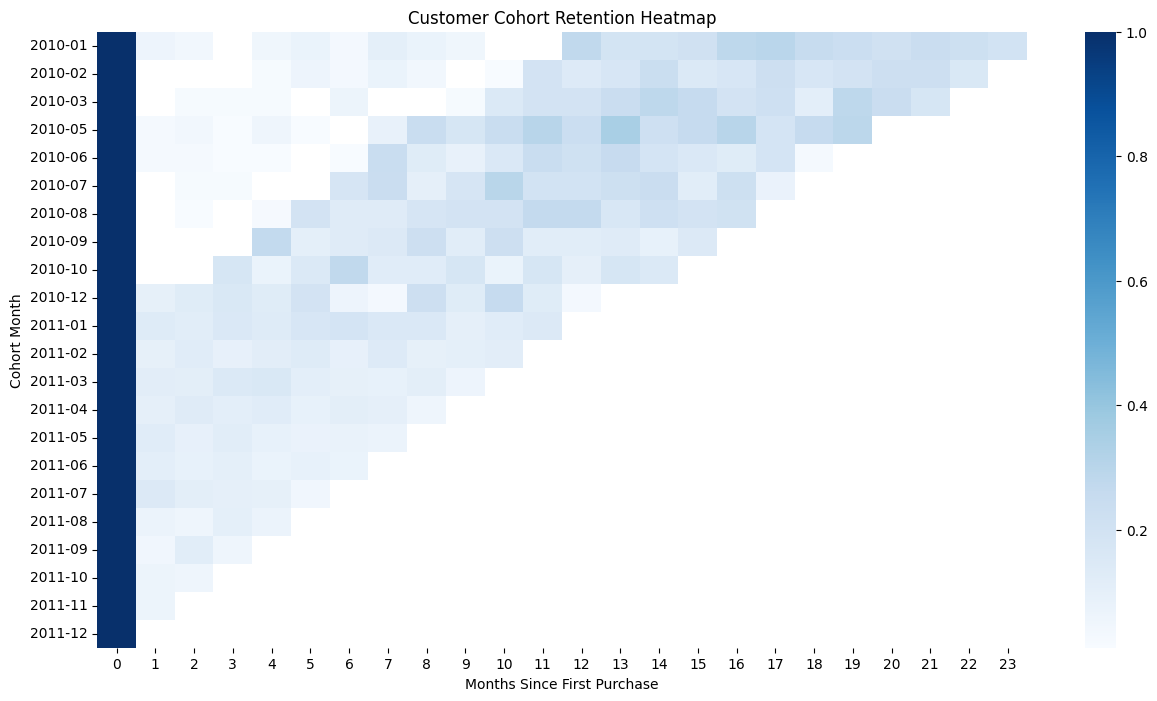

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(cohort_retention, annot=False, cmap='Blues')
plt.title('Customer Cohort Retention Heatmap')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()

In [32]:
avg_retention = cohort_retention.mean(axis=0)

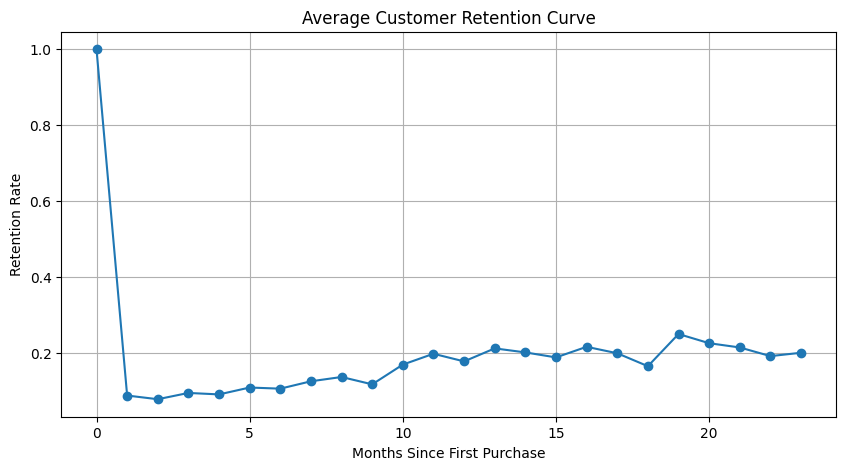

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(avg_retention.index, avg_retention.values, marker='o')

plt.title('Average Customer Retention Curve')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate')
plt.grid(True)
plt.show()